# 들어가며

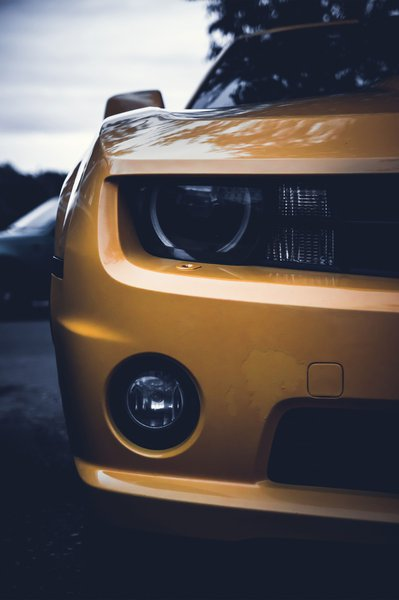

[Photo by Andrey Zvyagintsev on Unsplash]

반갑습니다, 순차적으로 코스를 밟아오셨다면 여러분은 지금쯤 지식이 제법 두터워지셨을 것 같군요. Word2Vec, Seq2seq, Attention... 멋진 기술들을 이해하고 자유자재로 사용할 수 있는 상태겠죠!

이번 코스에서는 자연어 처리의 꽃이라 불리는 **트랜스포머(Transformer)** 에 대해 알아볼 겁니다! 트랜스포머란 단어를 들을 때, 트랜스포머 모델이 낯선 분들은 유명한 영화 `<트랜스포머>`를 떠올리시겠지만, 자연어 처리를 열심히 공부했다면 오히려 영화가 어색하게 느껴지실 것입니다.

최근 자연어 처리 분야에서 혁명적인 발전의 토대가 된 정말 중요한 모델이니만큼, 코스가 포함하는 **모든 내용을 완벽히 이해하시길 적극 권장** 합니다. 물론 그러실 수 있게 좋은 자료들과 쉬운 설명들이 준비되어 있으니, 이번 코스도 파이팅!

**[아이스브레이킹] 자연어 처리의 꽃이라 불리는 트랜스포머(Transformer), 들어보셨나요?**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

네 들어 봤습니다!  
자연어 처리 분야에서 혁신적인 모델로 손꼽히며, 딥러닝 기반의 기계 번역, 챗봇, 문서 요약 등 다양한 자연어 처리 작업에 널리 사용되고 있습니다.

## 학습 내용
---
  - 2. Attention의 역사
    - Attention 개념을 학습합니다.
  - 3. Attention Is All You Need!
    - Transformer의 Attention 개념을 학습합니다.
  - 4. Positional Encoding
    - Positional Encoding 원리를 학습합니다.
  - 5. Multi-Head Attention
    - Multi-Head Attention 원리를 학습합니다.
  - 6. Position-wise Feed-Forward Networks
    - Position-wise Feed-Forward Networks 원리를 학습합니다.
  - 7. Additional Techniques
    - Add & Norm에 대해서 학습합니다.
  - 8. 트랜스포머, 그 후엔
    - BERT와 GPT에 대해서 학습합니다.

## 학습 목표
---
- 트랜스포머 이전의 Attention 기법에 대해 간단하게 설명할 수 있다.
- 트랜스포머에 포함된 모듈들을 심층적으로 이해할 수 있다.
- 트랜스포머를 발전시키기 위해 적용된 여러 테크닉들을 설명할 수 있다.

# Attention의 역사

트랜스포머를 본격적으로 다루기 전에 Seq2seq와 Attention 기법을 간단하게 복습해 봅시다!

**Q. 복습 전, 우리 Attention기법은 뭐였는지 간단하게 생각해 볼까요?**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

입력 시퀀스의 각 위치에 대해 가중치를 부여하여 중요한 정보에 집중하는 메커니즘입니다.  
Attention은 트랜스포머(Transformer) 모델에서 주로 사용되며, Seq2seq 모델의 성능을 향상시키고 장기 의존성 문제를 완화하는 데에도 사용됩니다.

**Sequence-to-sequence**(Seq2seq)는 신경망 언어 모델, 특히 기계번역에서 혁신적인 발전을 이룩해냈습니다. 기존의 단일 RNN은 번역에 적합한 구조가 아니었으나 두 개의 RNN을 결합한 Encoder-Decoder 구조를 만들어 문맥 전체를 반영한 번역이 가능하게 했죠.


```
Before)
Step 1: [나는] -> [I]
Step 2: [나는] [점심을] -> [I] [lunch]
Step 3: [나는] [점심을] [먹는다] -> [I] [lunch] [eat(?)]

After)
Encode(나는 점심을 먹는다)
-> 고정된 크기의 컨텍스트 벡터
-> Decode(컨텍스트 벡터) = I eat lunch!
```



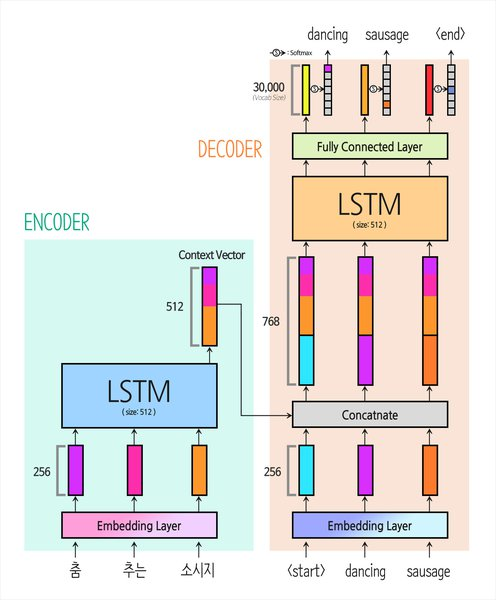

[Seq2seq 구조]

단순 RNN은 긴 입력에 대한 정보를 학습시키기 어렵기 때문에 Seq2Seq에서는 LSTM을 사용한 Encoder-Decoder 구조를 채택했습니다. 논문에서 사용된 표현을 빌리면, Encoder에 **Input** Sequence `x`를 넣으면 고정된 크기의 **Representation Vector** `v`에 모든 정보를 담아 Decoder에게 전달해 주는 구조입니다. Decoder는 전달받은 `v`를 기반으로 **Output** Sequence` y`를 생성합니다. 추가로 `v`는 **컨텍스트 벡터(context vector)** 라고 불리기도 하죠.

하지만 고정된 크기의 컨텍스트 벡터를 사용하는 것은 필연적으로 정보의 손실을 야기합니다. 특히 문장이 길어지면 더더욱 손실이 커집니다. 단순하게 생각해서 컨텍스트 벡터가 모든 Embedding의 평균이라 하면 3단어를 포함하는 문장과 100단어를 포함하는 문장 중 손실이 일어날 쪽은 당연히 후자겠죠?

그래서 모든 단어를 같은 비중으로 압축하지 말고, 번역하는 데에 중요한 단어만 큰 비중을 줘서 성능을 높여보자며 Dzmitry Bahdanau가 **Attention**을 제안합니다. Bahdanau Attention의 멋진 시각화를 보고 싶다면 아래 웹페이지를 참고하세요!

  - [Attn: Illustrated Attention](https://eda-ai-lab.tistory.com/157)

매 스텝의 Hidden State 값을 사용하는 것은 제법 효과가 좋았습니다. 실제로 그렇게 만들어진 Attention을 히트맵으로 출력하면 의미적으로 유사한 단어들끼리 연결되는 것을 볼 수 있었거든요.

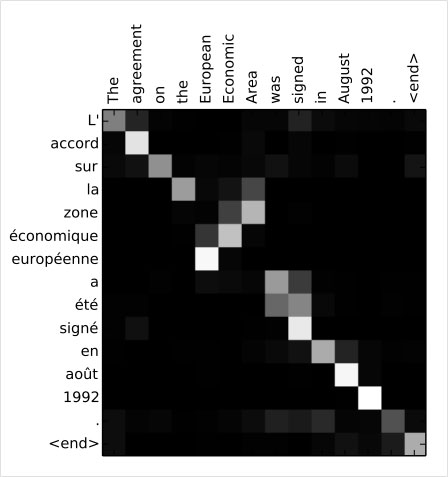

[Bahdanau Attention 논문에 포함된 Attention Map]

 https://arxiv.org/abs/1409.0473

대각선이 역행하는 `European Economic Area` 부분을 유심히 보시면 같은 의미의 불어 `zone economique europeenne`과 의미적으로 유사한 것들끼리 연결된 것을 볼 수 있습니다.

Bahdanau Attention의 문제라면 T 스텝에서 Decoder의 Hidden State를 구하기 위해 T-1 스텝의 Hidden State를 사용해야 한다는 것이었죠. 이는 재귀적으로 동작하는 RNN에 역행하는 연산이므로 효율적이지 못했습니다. 이를 개선하고자 한 것이 **Luong이 제안한 Attention** 기법입니다!

해당 기법에 대한 멋진 직관이 다시 필요하다면, 아래 웹페이지를 참고하세요!

  - [[Attention] Luong Attention 개념 정리](https://hcnoh.github.io/2019-01-01-luong-attention)

이러나저러나 NLP 세상에 Attention 붐이 온 것은 확실했습니다. 실제로 우리가 문장을 이해하는 방식과도 굉장히 유사하기에 "저건 무조건 발전해야 해!"라는 느낌을 주죠. 그리고 2017년, 이 흐름을 종결하기라도 하려는 듯 **Attention Is All You Need** 라는 충격적인 제목의 논문이 등장합니다.

# Attention Is All You Need!

**집중!** 이번 코스에서 여러분께 필요한 것도 오직 Attention입니다!

충격적인 제목의 논문은 그 내용마저도 충격적이었습니다. 서론의 한 구절을 살펴보죠.

>We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely.  
(우리는 RNN과 CNN을 완전히 배제하고 Attention 메커니즘에만 기반을 둔 새롭고 단순한 구조, Transformer를 제안합니다.)*

RNN과 CNN을 완전히 배제한다니! CNN은 자연어 처리에 있어서 흔히 사용되지는 않기 때문에 그럴 수 있다고 하지만 RNN은 고안된 배경이 애초에 언어를 모델링 하기 위함이었는데...

생각해 보면 그간 RNN은 많은 발전을 거듭했지만 그럼에도 고질병인 **기울기 소실(Vanishing Gradient)** 은 완벽히 해결되지 않았습니다. 그럼에도 울며 겨자 먹기로 문장 데이터의 순차적인 특성을 유지하기 위해 사용이 필연적이라 생각했지만... 고정관념이었던 거죠!

심지어 순차적으로 계산한다는 특성은 양날의 검이었습니다. 그 특성 때문에 **병렬 처리가 불가능하다** 는 것은 큰 문제점이었거든요. 이 또한 다들 지적은 하지만 마땅한 해결책이 없던 와중에 이를 배제할 수 있다니! **트랜스포머** 는 그야말로 신문물이었습니다. 이것이 바로 그 충격적인 논문입니다!

  - [Attention Is All You Need](https://arxiv.org/pdf/1706.03762)

논문이 포함하는 (거의) 모든 내용은 본 코스에서 다룰 예정입니다. 이 코스를 마치고 나서 복습하며 살펴보시는 것도 좋고, 지금 가볍게 읽어보시는 것도 좋습니다. 😃

저자들은 문장에서 **연속성이라는 개념을 과감히 배제** 하였습니다. 대신 Attention으로 **각 단어들의 상관관계를 구하는 데 집중** 하였죠. 일전에 배우셨듯이 문장을 모델링 한다는 것은 주어진 단어를 보고 모르는 단어에 확률을 할당하는 것입니다. 연속성이 배제된 채로 문장을 모델링 한다는 것은, 단순히 생각하면 입력으로 `빨간 사과 노란 바나나`가 들어가는 것과 `노란 사과 빨간 바나나`가 들어가는 것이 동일하게 취급되는 셈입니다.

RNN처럼 단어 입력을 순차적으로 처리하지도 않으면서 어떻게 문장을 정확히 처리해냈는지는 차근차근 이해해 보도록 하죠!

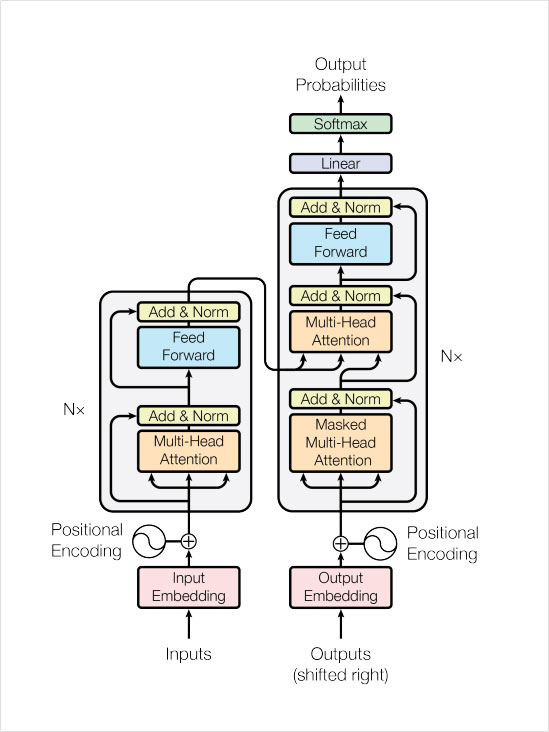

[트랜스포머의 구조]

트랜스포머도 엄밀하게는 Seq2seq에서 제안된 Encoder-Decoder 구조를 사용합니다. 대신 그 안에는 LSTM 대신 다양한 모듈들이 가득 차 있죠. 그리고 이 멋진 Encoder와 Decoder를 여러 개(논문에서는 6개) 쌓아올려 모델을 완성합니다.

>가끔 헷갈려 하시는 분들이 있어 첨언하면, Enc-Dec-Enc-Dec-... 구조가 아닌 Enc-Enc-...-Dec-Dec-... 구조입니다!

먼저 문장의 연속성을 어떻게 배제할 수 있었는지, 모델의 최하단에 위치한 **Positional Encoding** 부터 차근차근 알아보도록 하겠습니다.

# Positional Encoding

이번 스텝에서 우리가 살펴볼 부분은 아래의 **Positional Encoding** 부분입니다.

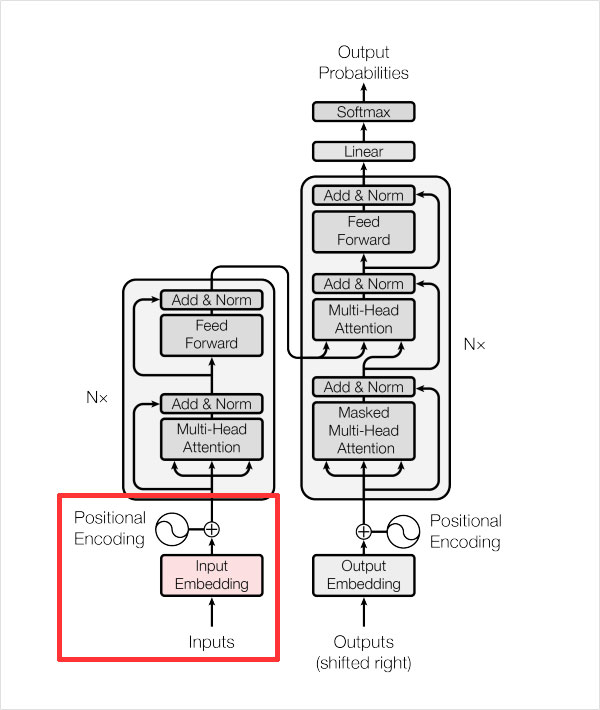

이전 스텝에서 문장의 연속성을 배제할 경우 `빨간 사과 노란 바나나`와 `노란 사과 빨간 바나나`를 같은 문장으로 간주하게 된다고 했죠? Positional Encoding은 그런 불상사를 막기 위한 방법입니다. 즉, **문장에 연속성을 부여하는 새로운 방법**을 제시한 거죠.

쉽게 말하면 입력이 들어온 순서대로 단어에 표기를 하는 것과 같습니다. 예를 들면 `[빨간 + 1] [사과 + 2] [노란 + 3] [바나나 + 4]`과 같은 모양새로 말이죠. 하지만 그렇다고 단어 Embedding에 선형적으로 증가하는 값을 더해줬다간 **후에 데이터의 분포가 엉망**이 될 겁니다. 문제없이 Position을 나타낼 수 있는 방법엔 어떤 것들이 있을까요? 아래 웹페이지에서 자세한 내용을 확인해보세요!

  - [jeongstudy: positional encoding이란 무엇인가](https://skyjwoo.tistory.com/31)

**Q. 글의 저자가 제시한 Positional Encoding의 두 가지 방법과 그 한계는 각각 무엇인가요?**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

각 단어에 0~1 사이의 값을 더한다. 0을 첫 번째 단어로, 1을 마지막 단어로 한다.  
-> 문장의 길이에 따라 더해지는 값이 가변적이다. 따라서 단어 간의 거리(Delta)가 일정하지 않다.

각 단어에 선형적으로 증가하는 정수를 더한다.  
-> 단어 간의 거리(Delta)가 일정해지는 것은 좋지만 범위가 무제한이기 때문에 값이 매우 커질 수 있고 모델이 일반화하기 어려워진다.

**Q. Positional Encoding이 만족해야 할 4가지 조건을 적어보세요.**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

각 Time-step마다 고유의 Encoding 값을 출력해야 한다.  
서로 다른 Time-step이라도 같은 거리라면 차이가 일정해야 한다.  
순서를 나타내는 값이 특정 범위 내에서 일반화가 가능해야 한다.  
같은 위치라면 언제든 같은 값을 출력해야 한다.

저자들이 사용한 Positional Encoding 수식은 아래와 같습니다.

$$PE_{(pos,2i)} = sin(pos/10000^{2i/d_{model}})$$
$$PE_{(pos,2i+1)} = cos(pos/10000^{2i/d_{model}})$$

pos는 단어가 위치한 Time-step을 의미하며 i는 Encoding 차원의 Index, $d_{model}$은 모델의 Embedding 차원 수입니다. 이를 **Sinusoid(사인파) Embedding**이라고 칭합니다. 이해를 돕기 위해 실제 구현을 확인해보죠.

In [1]:
import numpy as np

def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, int(i) / d_model)

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table

pos = 7
d_model = 4
i = 0

print("Positional Encoding 값:\n", positional_encoding(pos, d_model))

print("")
print("if pos == 0, i == 0: ", np.sin(0 / np.power(10000, 2 * i / d_model)))
print("if pos == 1, i == 0: ", np.sin(1 / np.power(10000, 2 * i / d_model)))
print("if pos == 2, i == 0: ", np.sin(2 / np.power(10000, 2 * i / d_model)))
print("if pos == 3, i == 0: ", np.sin(3 / np.power(10000, 2 * i / d_model)))

print("")
print("if pos == 0, i == 1: ", np.cos(0 / np.power(10000, (2 * i + 1) / d_model)))
print("if pos == 1, i == 1: ", np.cos(1 / np.power(10000, (2 * i + 1) / d_model)))
print("if pos == 2, i == 1: ", np.cos(2 / np.power(10000, (2 * i + 1) / d_model)))
print("if pos == 3, i == 1: ", np.cos(3 / np.power(10000, (2 * i + 1) / d_model)))

Positional Encoding 값:
 [[ 0.          1.          0.          1.        ]
 [ 0.84147098  0.99500417  0.00999983  0.9999995 ]
 [ 0.90929743  0.98006658  0.01999867  0.999998  ]
 [ 0.14112001  0.95533649  0.0299955   0.9999955 ]
 [-0.7568025   0.92106099  0.03998933  0.999992  ]
 [-0.95892427  0.87758256  0.04997917  0.9999875 ]
 [-0.2794155   0.82533561  0.05996401  0.999982  ]]

if pos == 0, i == 0:  0.0
if pos == 1, i == 0:  0.8414709848078965
if pos == 2, i == 0:  0.9092974268256817
if pos == 3, i == 0:  0.1411200080598672

if pos == 0, i == 1:  1.0
if pos == 1, i == 1:  0.9950041652780258
if pos == 2, i == 1:  0.9800665778412416
if pos == 3, i == 1:  0.955336489125606


사견이지만 어떤 개념을 이해할 때엔 효율적인 코드보다 직접 값을 대입해보며 하드 코딩을 해보는 것이 제법 도움이 됩니다. 위 예제의 경우, 직접 Positional Encoding의 1번째 열과 2번째 열을 4번째 행까지 구해보는 하드 코딩이 포함되어 있습니다. 혹시라도 수식의 각 요소들이 무엇을 의미하는지 와닿지 않는다면 소스를 분석하며 이해해 보세요!

또한 Position 값이 각 Time-step 별로 고유하다는 것을 시각화를 통해 확인해 볼 수 있습니다.

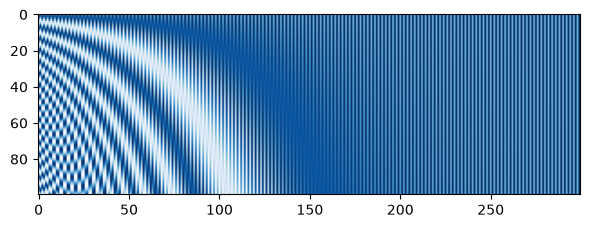

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.imshow(positional_encoding(100, 300), cmap='Blues')
plt.show()

세로축이 Time-step에 해당하고 가로축이 Word Embedding에 더해질 Position 값입니다. 한눈에 봐도 각 스텝마다 고유한 값을 가지는 것을 알 수 있죠? 게다가 굉장히 아름답습니다!

저자들은 이뿐만 아니라 **Positional Embedding** 기법도 제안했습니다. 수식적으로 계산한 Position 값이 아니라 Position에 대한 정보를 담은 Embedding 레이어를 선언하여 위치에 대한 정보를 학습할 수 있게 한 거죠. 그림으로 표현하면 아래와 같습니다.

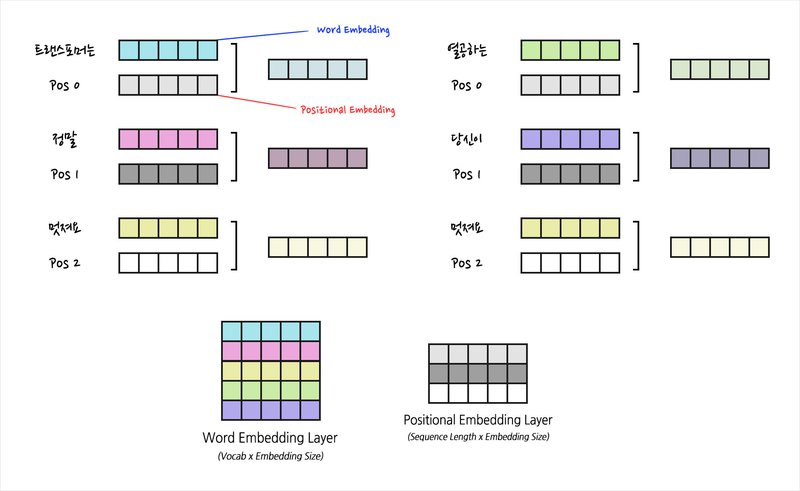

위와 같은 구조에서 Positional Embedding이 훈련 중 값이 변한다고 하더라도 그것은 **모든 문장에 대해 동일하게 적용**되기에 문제가 되지 않습니다. 오히려 Sinusoid Embedding보다 **적합한 값이 학습될 것을 기대**할 수도 있죠!

하지만 실제로는 두 방법 모두 거의 동일한(±0.1 BLEU) 결과를 보였으며, 저자들은 길이가 길어져도 부담이 없는 Sinusoid Embedding을 채택하였습니다. Positional Embedding은 문장의 길이만큼 Embedding Table의 크기가 커지니까요. Positional Embedding은 추후에 **BERT**라는 모델에 적용되어 멋진 성능을 보여줄 예정입니다!

# Multi-Head Attention

이번 스텝에선 트랜스포머의 핵심으로 꼽히는 **Multi-Head Attention** 에 대해 알아보겠습니다. Positional Embedding이 된 문장으로부터 Attention을 추출하는 부분이죠!

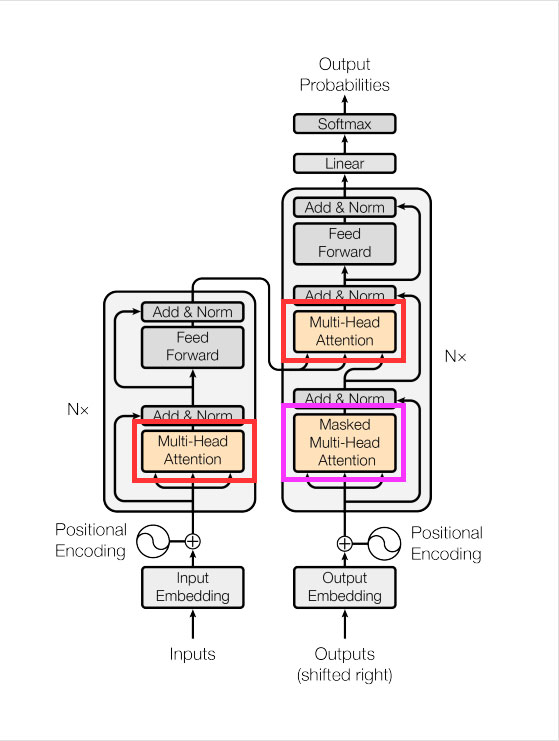

위 그림에서 보라색으로 표시된 Masked Multi-Head Attention은 Multi-Head Attention과 동일하지만 **인과 관계 마스킹(Causality Masking)** 이라는 과정이 하나 더 추가됩니다. 흐름에 따라 자연스럽게 후술하겠습니다!

Multi-Head Attention 모듈은 Linear 레이어와 Scaled Dot-Product Attention 레이어로 이루어집니다.

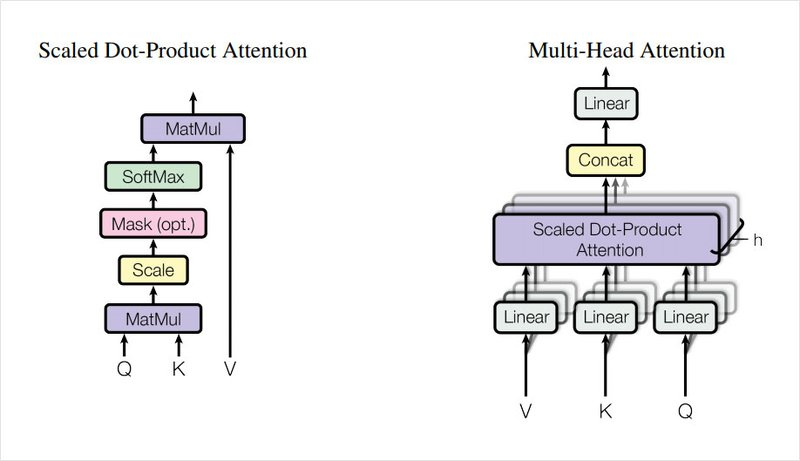

지금은 너무 헷갈리는 그림과 용어들일 수 있습니다, 차근차근 배워볼게요!

## Scaled Dot-Product Attention
---

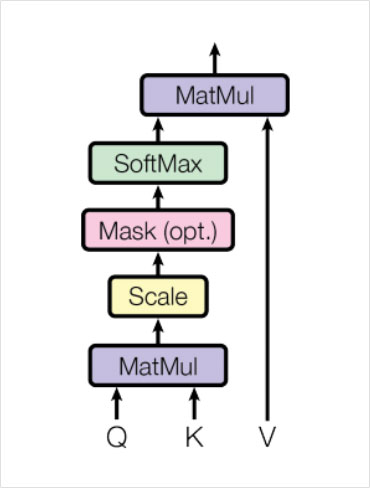

먼저 Scaled Dot-Product Attention에 대해 배워보겠습니다. 트랜스포머 논문 원문을 처음 읽게 될 때 맞닥뜨리게 되는 어려움 중 하나는, 수식도 이해되고 네트워크 구조도 이해할 수 있음에도 불구하고 그 의미가 직관적으로 잘 와닿지 않는다는 점인데요, 특히 그중에서도 위 그림에 나오는 Q(query), K(key), V(value)가 어떤 의미를 가지고 있는지 특별한 설명이 없다는 점입니다. 이 3가지의 의미는 오히려 후속 연구들을 통해 더욱 구체적으로 밝혀지고 있는데, 어쩌면 지금 이 시점까지도 계속 새롭게 그 의미가 드러나고 있다고도 할 수 있겠습니다.

하지만 2017년 시점으로 돌아가서, 이 Scaled Dot-Product Attention도 결국 그때까지 나왔던 attention 개념의 연장선이었음을 떠올려 봅시다. 그래서 이해를 돕기 위해 이전 시간에 다루어 보았던 Bahdanau attention 개념과 나란히 놓고 비교해 보겠습니다.

아래 그림의 오른쪽은 지난 시간에 다루었던 전통적인 attention 개념입니다. seq2seq 인코더-디코더 구조에서 attention이란 바로 디코더의 포지션 i에서 바라본 인코더의 context vector $c_i$를 해석하기 위해, 인코더의 각 포지션 j에 부여한 가중치였습니다. 이 가중치는 디코더의 state $s_i$와 인코더의 state $h_j$사이의 유사도를 통해 계산되었습니다.

원리는 동일합니다. 단지 디코더의 state를 Q(query)라고 부르고, 인코더의 state를 K(key)라고 추상화한 것입니다. 그래서 Q와 K의 유사도를 dot product로 계산하여 $\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)$를 attention 가중치로 삼고, 이것으로 V(value)를 재해석해 준 것입니다.

하나 다른 점은, 인코더 쪽에서 $h_j$ 하나만 존재하던 것이 K와 V 2가지로 분화되었다는 점입니다.

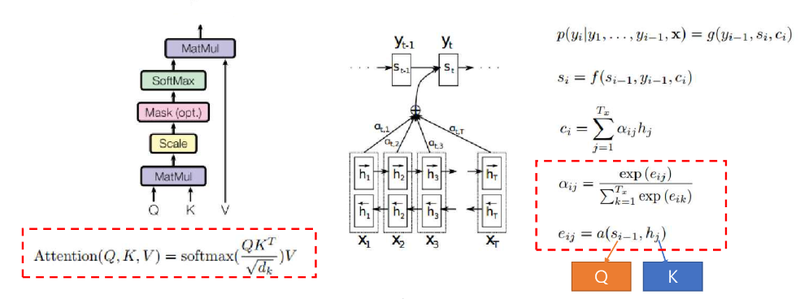

이제 여러분들은 위 그림에서 왼쪽 그림의 Attention(Q, K, V)와 오른쪽 그림의 $c_i$가 실은 같은 형태이며, $\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)$가 같은 역할을 하고 있다는 것이 눈에 들어오실 거라 생각합니다.

그럼 아래 웹페이지의 설명을 읽어본 후, 문답을 진행하며 좀 더 공부해 보도록 하죠! 글에서 **Scaled dot-product attention** 부분까지 읽으신 후 돌아오시길 바랍니다.

  - [reniew's blog: Transformer: Attention is all you need](https://reniew.github.io/43/)

**Q. Query와 Key를 Dot-Product한 후 Softmax를 취하는 것은 어떤 의미를 가지나요?**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

하나의 Query와 모든 Key들 사이의 연관성(유사도)을 계산한 후 그 값을 확률 값으로 만든다. 이는 Query가 어떤 Key와 높은 확률로 연관이 있는 지 계산한다.

$$\frac{1}{\sqrt{d_k}} : Scaled Dot-Product Attention$$

**Q. 트랜스포머의 Attention은 위의 식으로 Attention 값을 나눠준다는 것에서 "Scaled" Dot-Product Attention이라고 불립니다. 이 Scale 과정은 어떤 의미를 가지나요? (또는, 왜 필요한가요?)**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

Embedding 차원 수가 깊어지면 깊어질수록 Dot-Product의 값은 커지게 되어 Softmax를 거치고 나면 미분 값이 작아지는 현상이 나타난다. 그 경우를 대비해 Scale 작업이 필요하다.

정리하자면 Scaled Dot-Product Attention은 **Additive(합 연산 기반) Attention 과 Dot-Product(=Multiplicative, 곱 연산 기반) Attention** 중 후자를 사용한 Attention이고, 차원 수가 깊어짐에 따라 Softmax 값이 작아지는 것을 방지하기 위해 Scale 과정을 포함하였습니다. 이 과정을 본떠 **Scaled Dot-Product Attention** 이라고 이름이 붙여진 것이죠.

다만 Attention 속 Softmax의 성질을 이해하지 못한 상태라면 약간의 찜찜함이 남아있을 수 있습니다. 이를 해결하기 위해 간단한 코딩으로 직접 값을 확인해 보도록 하죠!

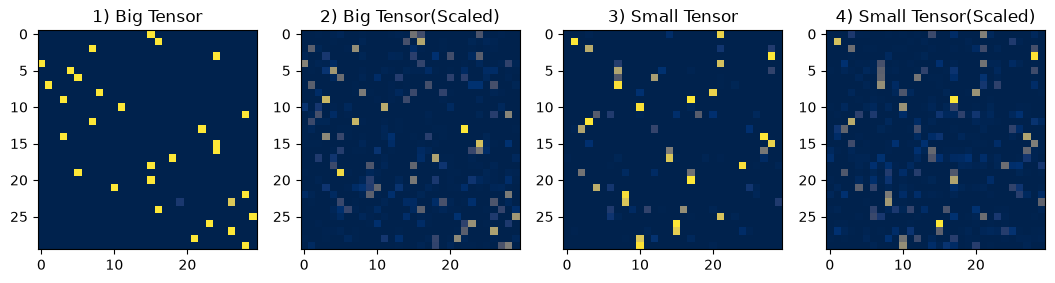

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def make_dot_product_tensor(shape):
    # TF의 tf.random.uniform([-3, 3]) + transpose + tensordot 을 PyTorch로 변환
    A = torch.empty(shape).uniform_(-3, 3)
    B = torch.empty(shape).uniform_(-3, 3).transpose(0, 1)
    return torch.matmul(A, B)

length = 30
big_dim = 1024.
small_dim = 10.

big_tensor = make_dot_product_tensor((length, int(big_dim)))
scaled_big_tensor = big_tensor / torch.sqrt(torch.tensor(big_dim))
small_tensor = make_dot_product_tensor((length, int(small_dim)))
scaled_small_tensor = small_tensor / torch.sqrt(torch.tensor(small_dim))

fig = plt.figure(figsize=(13, 6))

ax1 = fig.add_subplot(141)
ax2 = fig.add_subplot(142)
ax3 = fig.add_subplot(143)
ax4 = fig.add_subplot(144)

ax1.set_title('1) Big Tensor')
ax2.set_title('2) Big Tensor(Scaled)')
ax3.set_title('3) Small Tensor')
ax4.set_title('4) Small Tensor(Scaled)')

ax1.imshow(F.softmax(big_tensor, dim=-1).numpy(), cmap='cividis')
ax2.imshow(F.softmax(scaled_big_tensor, dim=-1).numpy(), cmap='cividis')
ax3.imshow(F.softmax(small_tensor, dim=-1).numpy(), cmap='cividis')
ax4.imshow(F.softmax(scaled_small_tensor, dim=-1).numpy(), cmap='cividis')

plt.show()

모두 같은 범위인 [-3, 3]에서 랜덤 Tensor를 만들어 실제 Attention을 하듯 Dot-Product를 하고, Softmax를 취했습니다. 위 히트맵에서 어두운 부분으로는 **미분 값(Gradient)** 이 흐르기 어렵기 때문에 모델이 넓은 특성을 반영할 수 없게 됩니다. 즉, 히트맵이 **선명할수록 모델의 시야가 편협해진다** 고 이해하시면 좋아요!

위 시각화를 통해 Embedding의 깊이가 깊을수록 모델의 시야가 편협해지는 문제가 생기고`[1, 3]`, Scale은 그 문제의 훌륭한 해결책임을 확인할 수 있습니다`[2, 4]`. 심지어 깊이에 무관하게 일정한 결과를 만들어내므로 어떤 경우에도 적용할 수 있는 훌륭한 Attention 기법이 탄생했음을 알 수 있습니다!

## 인과 관계 마스킹(Causality Masking)
---
이 놀라운 Attention 기법에 대해 배울 것이 아직 하나 더 남아있습니다. 앞서 언급한 **인과 관계 마스킹(Causality Masking)** 이 바로 그것입니다!

Sequence-to-sequence 모델을 훈련할 때에 Decoder의 첫 입력으로 `<start>` 토큰이 들어가던 것을 기억하실 겁니다. 그럼 Decoder는 컨텍스트 `벡터로 압축된 입력 문장`과 `<start>` 토큰만을 단서로 첫 번째 단어를 생성해야 하죠. 그다음 스텝도 같은 단서에 추가로 방금 Decoder 본인이 생성한 첫 번째 단어를 포함하여 두 번째 단어를 생성합니다. 이 같은 특성을 **자기 회귀(Autoregressive)** 라 칭합니다. 자기 자신을 입력으로 하여 자기 자신을 예측하는 것이죠.

하지만 트랜스포머는 모든 단어를 병렬적으로 처리하기에 **자기 회귀적인 특성을 잃어버립니다.** 이는 곧 문장을 생성할 수 없다는 의미이고, 쓸모가 없다는 얘기죠!

이에 저자들이 자기 회귀적인 특성을 살리기 위해 추가한 것이 바로 **인과 관계 마스킹(Causality Masking)** 입니다! 인과 관계 마스킹은 목표하는 문장의 일부를 가려 **인위적으로 연속성을 학습** 하게 하는 방법입니다. 말보단 그림으로 살펴보시죠!

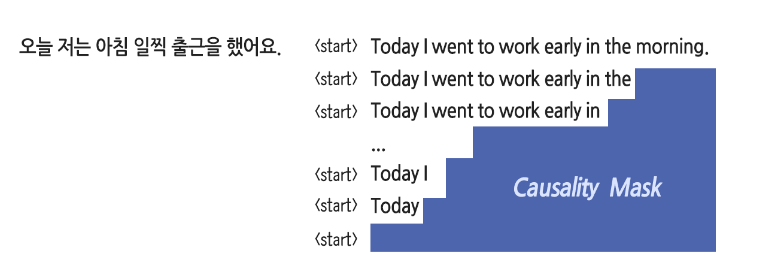

위와 같은 과정을 거치면 모든 Time-Step에 대한 입력을 한 번에 처리하면서 **자기 회귀적인 특성도 유지**하게 됩니다. 테스트 시 소스 문장을 Encoder에 전달하고 타겟 문장은 `<start>`만 넣더라도 모델이 `<start>` 토큰만 보고 문장을 생성한 적(위 그림의 마지막 Step)이 있기 때문에 첫 번째 단어를 생성해낼 수 있고, 생성된 단어는 다시금 입력으로 전달되어 그야말로 **자기 회귀적으로 문장을 생성**하게 됩니다.

이러한 연유로 인과 관계 마스크는 대각항을 포함하지 않는 **삼각 행렬**의 모양새를 갖습니다. 입력 문장만을 보고 첫 번째 단어를 생성하는 것은 타겟 문장을 모두 가리는 것이 타당하니 대각항을 포함하는 게 맞지만, 그럴 경우 Attention 값을 구하는 과정에서 마지막(혹은 첫 번째) 행이 0개 요소에 대해 Softmax를 취하게 되므로 오류를 야기합니다. 따라서 `<start>` 토큰을 활용해 마스크가 대각항을 포함하지 않는 형태가 되게끔 만든 것이죠.

(참고) 대각항(diagonal entry)이란 행렬에서 행과 열의 지표수가 같은 성분(대각성분)을 말합니다. 행렬에 대한 개념을 복습하시려면 [여기](https://sensol2.tistory.com/26)를 참고해 주세요.

지금 바로 코드로 이해해 볼까요?

C:\Users\heeji\AppData\Local\Temp\ipykernel_29544\2138156988.py:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax1.imshow((torch.ones(sample_tensor.shape) + mask).numpy(), cmap='cividis')


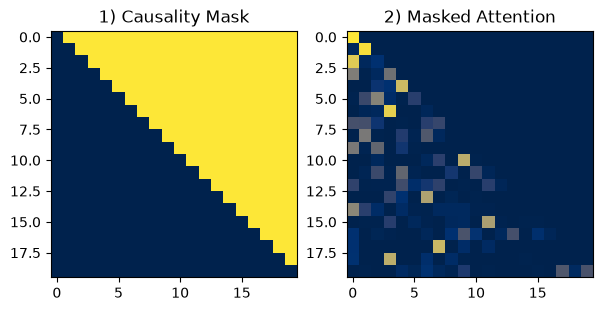

In [4]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def make_dot_product_tensor(shape):
    A = torch.empty(shape).uniform_(-3, 3)
    B = torch.empty(shape).uniform_(-3, 3).transpose(0, 1)
    return torch.matmul(A, B)

def generate_causality_mask(seq_len):
    # 아래쪽 삼각(자기 자신 포함)은 0, 위쪽(미래)은 -1 이 되도록 만든 마스크
    mask = 1 - np.cumsum(np.eye(seq_len, seq_len), 0)
    return mask

sample_tensor = make_dot_product_tensor((20, 512))
sample_tensor = sample_tensor / torch.sqrt(torch.tensor(512.))

mask = generate_causality_mask(sample_tensor.shape[0])

fig = plt.figure(figsize=(7, 7))

ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.set_title('1) Causality Mask')
ax2.set_title('2) Masked Attention')

ax1.imshow((torch.ones(sample_tensor.shape) + mask).numpy(), cmap='cividis')

mask = mask * -1e9
masked = sample_tensor + torch.tensor(mask, dtype=sample_tensor.dtype)
ax2.imshow(F.softmax(masked, dim=-1).numpy(), cmap='cividis')

plt.show()

좌측은 실제 마스크의 형태, 우측은 마스킹이 적용된 Attention입니다. 마스킹은 **마스킹 할 영역을 -∞**로 채우고 **그 외 영역을 0**으로 채운 배열을 Dot-Product된 값에 더해주는 방식으로 진행됩니다. 후에 진행될 Softmax는 큰 값에 높은 확률을 할당하는 함수이므로 -∞로 가득 찬 마스킹 영역에는 무조건 0의 확률을 할당하게 됩니다.

## Multi-Head Attention
---

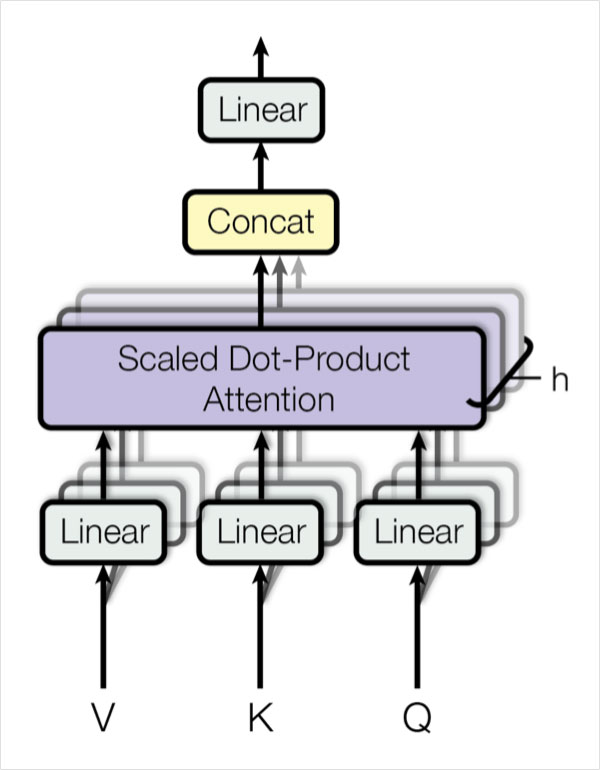

Scaled Dot-Product Attention에서 정말 많은 이야기를 했는데, 그것을 이해하고 나면 정작 Multi-Head Attention 모듈은 간단합니다. 일전에 Embedding이 어떤 추상적인 속성을 담고 있다고 배웠던 것, 기억하시나요? Multi-Head Attention은 그 개념을 활용해서 이해를 하면 아주 쉽습니다.

`바나나`라는 단어가 512차원의 Embedding을 가진다고 가정합시다. 그중 64차원은 노란색에 대한 정보를 표현하고, 다른 64차원은 달콤한 맛에 대한 정보를 표현할 겁니다. 같은 맥락으로 `바나나`의 형태, 가격, 유통기한까지 모두 표현될 수 있겠죠. 저자들은 '이 모든 정보들을 섞어서 처리하지 말고, 여러 개의 Head로 나누어 처리하면 **Embedding의 다양한 정보를 캐치**할 수 있지 않을까?' 라는 아이디어를 제시합니다.

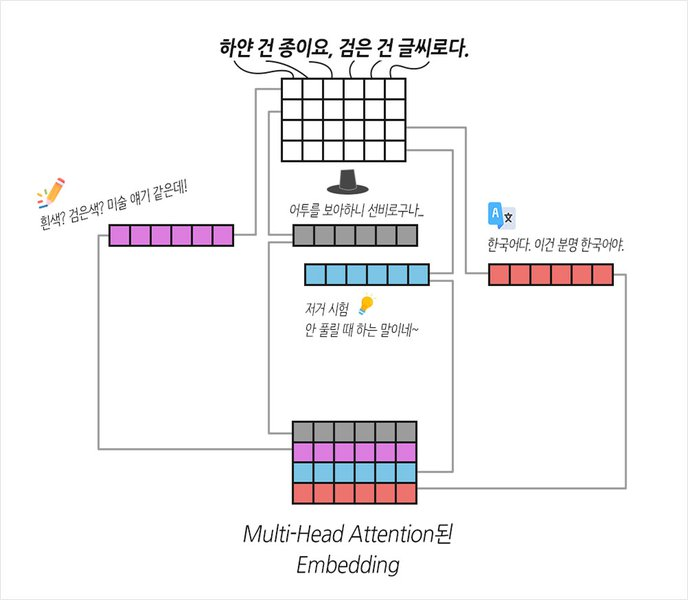

[Head가 4개인 Multi-Head Attention이라면... 이런 느낌?]

Multi-Head Attention에서 **Head는 주로 8개**를 사용합니다. Embedding된 10개 단어의 문장이 `[10, 512]`의 형태를 가진다면, Multi-Head Attention은 이를 `[10, 8, 64]`로 분할하여 연산합니다. 각 64차원의 Embedding을 **독립적으로 Attention**한 후, 이를 이어붙여 다시금 `[10, 512]`의 형태로 되돌리며 연산은 끝이 납니다.

>"에이, 쪼개진 64차원이 연관 있는 것들끼리 묶여있을 거란 보장이 없잖아요~"

위와 같은 의문을 가졌다면 잘하셨습니다! Head로 쪼갠 Embedding들끼리 유사한 특성을 가진다는 보장이 없기 때문에 **앞단에 Linear 레이어를 추가**해 주는 겁니다. Linear 레이어는 데이터를 특정 분포로 매핑 시키는 역할을 해주기 때문에, 설령 단어들의 분포가 제각각이더라도 Linear 레이어는 Multi-Head Attention이 잘 동작할 수 있는 **적합한 공간으로 Embedding을 매핑**합니다.

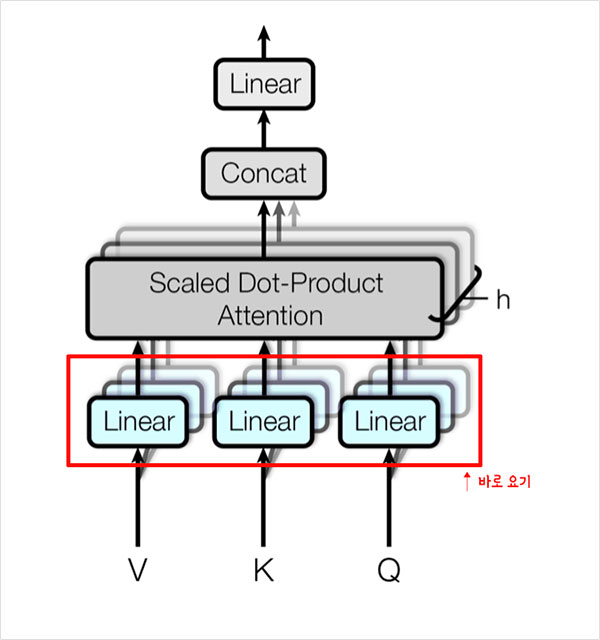

비슷한 이유로 각각의 Head가 Attention 한 값이 균일한 분포를 가질 거란 보장이 없습니다. 따라서 모든 Attention 값을 합쳐준 후, **최종적으로 Linear 레이어**를 거치며 비로소 Multi-Head Attention이 마무리가 됩니다.

# Position-wise Feed-Forward Networks

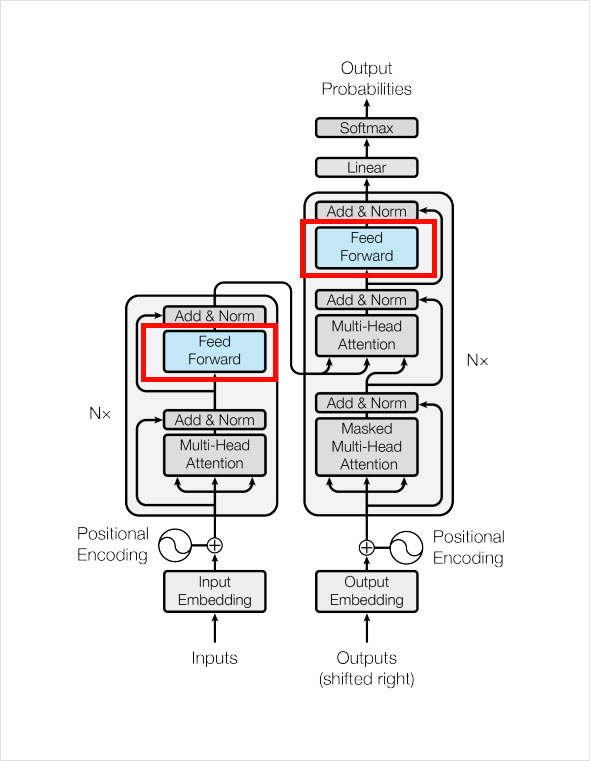

Position-wise Feed-Forward Network는 위의 Multi-Head Attention만큼 센세이셔널하지는 않습니다. 그래서 논문에서도 큰 분량을 차지하지 않는 개념이죠. 양이 많지 않으니 논문의 구절을 그대로 읽어보시는 것을 추천드립니다.

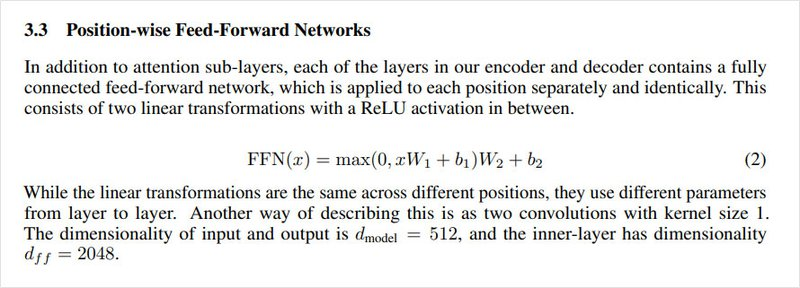

**W**는 Linear 레이어를 의미하고, **max(0, x)** 함수는 활성 함수 ReLU입니다. 예를 들면 10단어로 이루어진 Attention된 문장 `[10, 512]`를 `[10, 2048]` 공간으로 매핑, 활성함수를 적용한 후 다시 `[10, 512]` 공간으로 되돌리는 것입니다. 이를 그림을 더해 쉽게 설명한 글을 첨부해드리니 읽어보세요! `Position-wise Feed-Forward Networks` 부분입니다.

  - [Attention is all you need paper 뽀개기](https://pozalabs.github.io/transformer/)

**Q. FFN 앞에 Position-Wise라는 수식이 붙는 이유는 무엇인가요?**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

FFN 연산이 개별 단어(Position)마다 적용되기 때문이다.

**Q. (OX문제)앞서 트랜스포머는 여러 개의 Encoder와 Decoder를 쌓아 완성한다고 했는데요. 각 레이어의 Position-wise Feed-Forward Networks는 Parameter를 공유하나요?**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

X  
레이어가 달라지면 다른 Parameter를 사용한다.

설명 중 와닿지 않는 부분을 하나 꼽으라면, 많은 분들이 이 모듈이 **커널 사이즈가 1인 Convolution을 두 번 연산한 것과 동일하다고 하는 부분**일 거라 예상합니다. 생각보다 이 Linear 연산을 CNN으로 구현한 것도 많고 논문에서도 Convolution으로 언급하는 경우가 종종 있어 지금 이해해두시면 좋습니다.

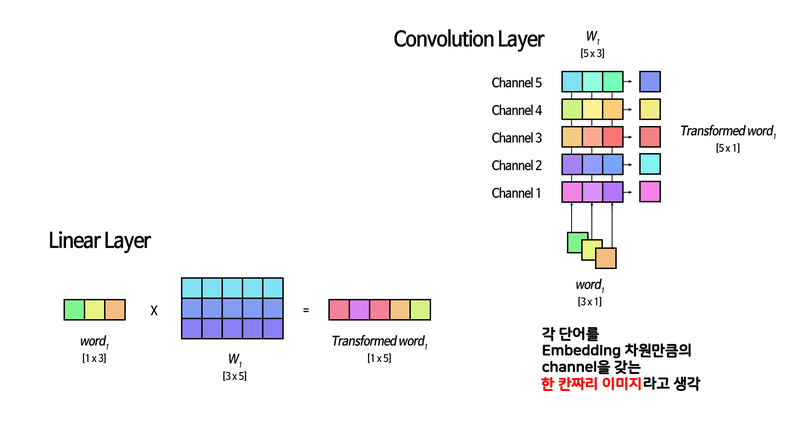

한 단어를 Embedding 차원만큼의 채널을 갖는 이미지라고 취급한다면 이해가 되실 겁니다. Convolution 레이어의 Weight는 `[입력 차원 수 X 출력 차원 수 X 커널의 크기]` 이므로 커널의 크기가 1이라면 Linear 레이어와 동일한 크기의 Weight를 갖게 되죠.

최근에는 구글에서 AI를 만드는 AI, AutoML을 활용해 최적의 트랜스포머 구조를 찾아내기도 했습니다. **진화된 트랜스포머(Evolved Transformer)** 는 두 층의 레이어 중 아래층 레이어에서 차이를 보이는데, 이때 Linear 레이어를 Convolution 레이어로 표기하는 방식을 택합니다. 궁금하신 분들은 아래 웹페이지에서 진화된 트랜스포머의 구조를 살펴보세요! (글은 지금 읽지 않으셔도 괜찮습니다.)

  - [Applying AutoML to Transformer Architectures](https://research.google/blog/applying-automl-to-transformer-architectures/)

# Additional Techniques

여기까지 트랜스포머의 큰 줄기는 다 배웠습니다. 이제 세부 줄기에 대해서 살펴볼 건데요, 이 세부 줄기가 별거 아닌 것 같아 보여도 성능에 제법 영향을 끼치니 놓치는 부분 없이 잘 숙지하시길 바랍니다!

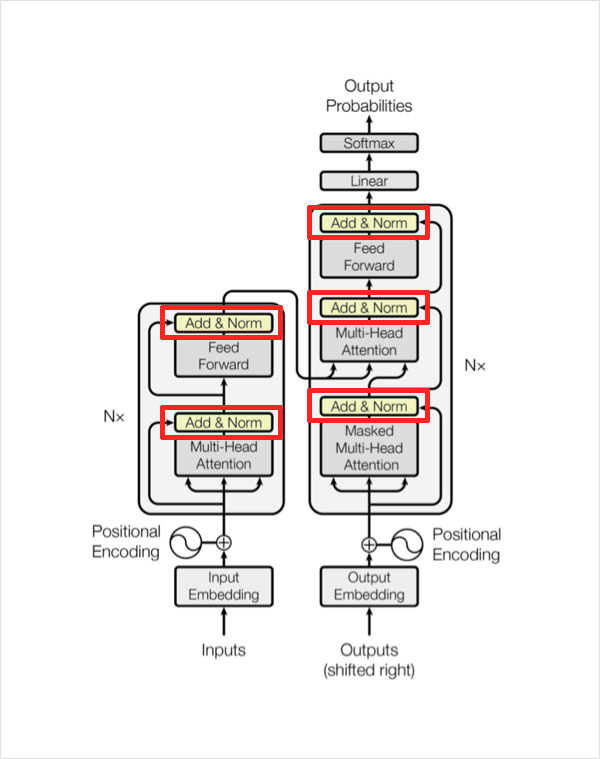

먼저 그림 상으로 우리가 배우지 않은 유일한 모듈, `Add & Norm` 에 대해 파헤쳐 보도록 하죠!

## Layer Normalization
---
Layer Normalization은 데이터를 Feature 차원에서 정규화를 하는 방법입니다. 또다시 10단어의 Embedding된 문장을 예로 `[10, 512]`에서 512차원 Feature를 정규화하여 **분포를 일정하게 맞춰주는 것**이죠. Layer Normalization 외에도 다양한 Normalization 방법이 있고, 약간 논외지만 Regularization과 Generalization 등 우리를 헷갈리게 하는 많은 방법들이 있습니다. 다행히도 아랫글에서 모든 개념을 쉽게 정리해 주고 있으니, 살펴보시길 적극 권장합니다!

  - [Introduction to Deep Learning Normalization](https://subinium.github.io/introduction-to-normalization/)

**Q. 데이터 Feature의 Scale을 직접적으로 조정하는 방법은 무엇인가요? 그 이유로 Feature Scaling이라고 불리기도 합니다!**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

정규화(Normalization)

**Q. Batch Normalization과 Layer Normalization의 차이점을 적어주세요. (대표적인 한 가지만 적어도 충분합니다!)**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

Batch Normalization은 정규화를 Batch 차원에서 진행하는 것이고 Layer Normalization은 정규화를 Feature 차원에서 진행하는 것이다.

Normalization 기법은 비단 트랜스포머뿐만 아니라 어떤 모델에서도 성능 향상을 이끌어낼 수 있는 기법이니 확실하게 알아두시길 바랍니다.

## Residual Connection
---
Skip Connection이라고도 부르는 Residual Connection이 처음 제안된 것은 2015년 ResNet이라는 모델과 함께였습니다. **ResNet**은 자연어 처리를 공부하는 우리에겐 다소 낯선 이름인데요, 컴퓨터 비전에서는 트랜스포머만큼이나 유명한 모델이랍니다! 모델 자체를 완벽히 이해할 필요는 없지만, 등장 배경이 된 멋진 아이디어는 알아두면 좋습니다. 아래 웹페이지에서 좋은 맛보기 자료를 제공해 주고 있네요!

  - [(7) ResNet (Residual Connection)](https://itrepo.tistory.com/36)

**Q. 상식적으로 56개의 레이어를 갖는 네트워크는 20개의 레이어를 갖는 네트워크보다 성능이 좋아야 합니다. 하지만 그렇지 않았죠! 이유가 무엇인가요?**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

네트워크가 깊어질 수록 Optimize(Train)하는 것이 어렵기 때문에, 얕은 네트워크가 더 좋은 성능을 보이게 된다.

**Q. Residual Block은 굉장히 간단한 수식으로 표현이 가능합니다. 수식을 적어보세요.**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

y = f(x) + x

아주 단순한 아이디어지만, 그 내면에는 깊은 수학적 통찰이 포함되어 있습니다. 트랜스포머를 이해하는 데에는 위의 정보만으로도 충분하지만 ResNet의 등장 배경에 대해 더 알아보고 싶으시다면 아랫글을 참고해보세요!

  - [Detailed Guide to Understand and Implement ResNets](https://cv-tricks.com/keras/understand-implement-resnets/)

## Learning Rate Schedular
---
트랜스포머를 훈련하는 데에는 Adam Optimizer를 사용했는데, 특이한 점은 Learning Rate를 수식에 따라 변화시키며 사용했다는 것입니다. 수식은 아래와 같습니다.

$$\text{lrate} = d_{\text{model}}^{-0.5} \cdot \min(\text{step\_num}^{-0.5}, \text{step\_num} \cdot \text{warmup\_steps}^{-1.5})$$

위 수식을 따르게 되면 warmup_steps까지는 $lrate$가 **선형적으로 증가** 하고, 이후에는 step_num에 비례해 **점차 감소하는 모양새** 를 보이게 됩니다.

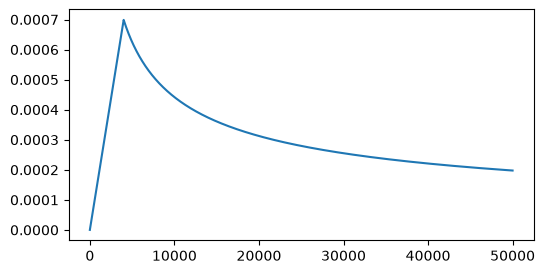

In [5]:
import matplotlib.pyplot as plt
import numpy as np

d_model = 512
warmup_steps = 4000

lrates = []
for step_num in range(1, 50000):
    lrate = (np.power(d_model, -0.5)) * np.min(
        [np.power(step_num, -0.5), step_num * np.power(warmup_steps, -1.5)])
    lrates.append(lrate)

plt.figure(figsize=(6, 3))
plt.plot(lrates)
plt.show()

이와 같은 Learning Rate를 사용하면 **초반 학습이 잘되지 않은 상태에서의 학습 효율**이 늘어나고, 어느 정도 학습이 된 후반에는 **디테일한 튜닝**을 통해 Global Minimum을 찾아가는 효과가 나게 됩니다. 학습의 초반과 후반은 `warmup_steps` 값에 따라 결정되고요. 직관적으로도 멋진 개념입니다!

## Weight Sharing
---
Weight Sharing은 모델의 일부 레이어가 동일한 사이즈의 Weight를 가질 때 종종 등장하는 테크닉입니다. **하나의 Weight를 두 개 이상의 레이어가 동시에 사용**하도록 하는 것인데, 대표적으로 언어 모델의 Embedding 레이어와 최종 Linear 레이어가 동일한 사이즈의 Weight를 가집니다. 프로그래밍 개념 중 `Call By Reference`와 비슷한 느낌이죠!

이는 가볍게 생각했을 때에는 비효율적일 것으로 보입니다. 출력층의 Linear 레이어는 그만의 역할이 있을 것이고 Embedding 레이어 또한 그럴 것인데, 둘을 서로 엮어버리면 이도 저도 아닐 것 같은 느낌이 들죠. 하지만 앞서 ResNet이 증명한 것처럼 많은 **Weight가 곧 성능으로 이어지지 않고**, 외려 **Optimization에서 불리한 경향**을 보인다는 것을 생각하면 이해가 갈 거예요.

실제로 Weight Sharing은 튜닝해야 할 파라미터 수가 감소하기 때문에 학습에 더 유리하며 자체적으로 Regularization 되는 효과도 있습니다. 유연성이 제한되어 과적합을 피하기 용이해지거든요!

트랜스포머에서는 **Decoder의 Embedding 레이어**와 **출력층 Linear 레이어**의 Weight를 공유하는 방식을 사용했습니다. 소스 Embedding과 타겟 Embedding도 논문상에서는 공유했지만 이는 언어의 유사성에 따라서 선택적으로 사용합니다. 만일 소스와 타겟 Embedding 층까지 공유한다면 3개의 레이어가 동일한 Weight를 사용하는 셈이죠.

또한 출력층 Linear 레이어와 Embedding 레이어의 Feature 분포가 다르므로 Embedding 된 값에 $d_{model}$의 제곱근 값을 곱해줍니다. 이는 분포를 맞춰줌과 동시에 Positional Encoding이 Embedding 값에 큰 영향을 미치는 것을 방지해 줍니다.

# 트랜스포머, 그 후엔

트랜스포머가 NLP의 꽃이라는 것은 학계의 수많은 관련 논문들이 증명합니다! 이번 스텝에서는 트랜스포머를 기반으로 발전한 큰 줄기들을 간단하게 소개해 드리겠습니다.

가장 먼저 등장한 것은 **BERT**와 **GPT**였습니다. 두 모델 다 엄청난 양의 데이터를 기반으로 훈련되어 경이로운 성능을 보여줬죠. 이들을 잘 소개한 글을 첨부합니다. 아랫글을 읽고 다음 질문에 답해 주세요.

  - [BERT와 GPT](https://ratsgo.github.io/nlpbook/docs/language_model/bert_gpt/#gpt)

**Q. GPT와 BERT의 차이점에 대해 3가지만 적어보세요.**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

GPT는 단방향 Attention을 사용하지만 BERT는 양방향 Attetion을 사용한다.  
GPT는 트랜스포머에서 디코더(decoder)만 사용하고 BERT는 인코더(encoder)만 사용한다.  
GPT는 문장을 생성할 수 있지만 BERT는 문장의 의미를 추출하는 데 강점을 가지고 있다.

오늘 소개한 트랜스포머는 `max_sequence_length`를 512에서 1024 정도로만 사용합니다. 그래서 초기에는 주로 몇 개 문장 단위의 번역 작업에 활용되었죠. **문단의 문맥을 파악하는** 수준까지의 보다 긴 입력 길이를 처리할 수 있도록, 기존의 트랜스포머에 Recurrence라는 개념을 추가한 **Transformer-XL**이 제안되기도 했습니다. 간단한 이해를 하기에는 아랫글이 아주 적합합니다!

  - [Transformer-XL 자료 정리 및 설명요약](https://comeng.tistory.com/entry/Transformer-XL-%EC%9E%90%EB%A3%8C%EC%A0%95%EB%A6%AC-%EB%B0%8F-%EC%84%A4%EB%AA%85%EC%9A%94%EC%95%BD)

지금에 이르러서는 모델 성능이 극대화되어 성능을 높이고자 하는 연구보단 연산량을 줄이고자 하는 연구가 늘고 있습니다. **Reformer**는 트랜스포머를 **연산량 측면에서 혁신적으로 개선**한 모델입니다. 이 역시 멋진 정리 글을 첨부합니다!

  - [Reformer:효율적인 트랜스포머](https://brunch.co.kr/@synabreu/31)

이 흐름에서 등장한 재미있는 아이디어 중 하나는 "Multi-Head Attention에서 모든 Head가 과연 필요한가?" 라는 주장입니다. 이 또한 시야를 넓히는 데에 도움이 되니 가볍게 읽어보시길 권장합니다!

  - [월간 자연어 처리 - MHA](https://www.facebook.com/permalink.php?story_fbid=156092245822648&id=111809756917564)
  - [(논문리뷰) Are Sixteen Heads Really Better than One?](https://littlefoxdiary.tistory.com/m/66?category=847374)

이 외에도 **XLNet, ELECTRA, RoBERTa, GPT-3**... 놀라운 것들은 너무나도 많지만 우리에게 주어진 시간이 한정적이니 필요한 것을 빠르게 훑는 기술도 필요하겠죠. 위에 소개해드린 큰 줄기 중 관심이 동하는 부분이 있다면 그쪽으로 파생된 모델들을 차근차근 훑어가는 것도 좋은 공부가 될 것 같네요!

# 마무리하며

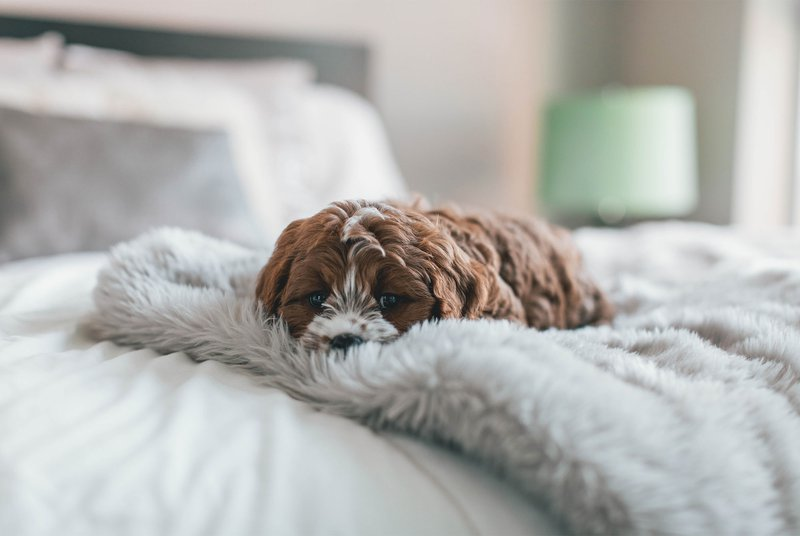

이렇게 트랜스포머에 대한 모든 것을 배워보았습니다. 모든 것이 선명하게 그려지지는 않을 거예요. 다만 앞으로 배울 것들에 수도 없이 등장할 트랜스포머 기반 모듈에 당황하는 일이 없으시기를 바랄 뿐입니다!

## 종합퀴즈
---
지금까지 여러분들이 얼마나 학습을 충실히 하셨는지 알아볼까 합니다.  
여러분의 실력을 쑥쑥 향상시켜줄 수 있는 퀴즈이기도 하므로 배운 내용을 다시 생각하면서 아래의 퀴즈를 풀어보세요. 🤗

**Q. Positional Encoding에 대해서 간단하게 설명해 볼까요?**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

입력 시퀀스의 단어 위치 정보를 인코딩하는 데 사용됩니다.

Transformer 모델은 입력 데이터를 처리할 때 단어의 순서 정보를 고려하지 않습니다. 그러나 자연어 처리에서는 단어의 순서가 중요한 역할을 하는 경우가 많기 때문에 이를 해결하기 위해 Positional Encoding이 도입되었습니다.

**Q. BERT와 GPT에 대해서 간단하게 설명해 볼까요?**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

BERT와 GPT는 모두 Transformer 아키텍처를 사용하여 강력한 자연어 처리 능력을 갖추고 있습니다.

하지만 BERT는 양방향 인코더를 사용하여 문맥을 이해하고, GPT는 디코더를 사용하여 텍스트를 생성하는 데 초점을 맞추고 있습니다. 두 모델은 각각의 특성에 따라 다양한 자연어 처리 작업에서 유용하게 활용될 수 있습니다.

종합 퀴즈는 괜찮았나요?
학습을 충실히 하셨다면 쉽게 해결하셨을 것이라 생각합니다.

여러모로 어텐션을 왕창하셨으니 피곤하시리라 생각합니다. 오늘은 맘 편하게 쉬셔도 괜찮아요! 뿌듯함도 잔뜩 느끼세요. 왜냐면 오늘 배운 것은 정말 크고 중요한 거니까요..!

이제 트랜스포머 하면 영화 보단 자연어 처리가 먼저 떠오르겠죠? 벌써 멋진 인공지능 연구자가 되었다는 증거입니다. 😃 고생하셨습니다!